# STEP 2

# Import libraries

In [1]:
import matplotlib.pyplot as plt
import dhnx
import pandas as pd
import oemof.solph
from pyomo.environ import SolverFactory

Need to install geopandas to process osm data.
Need to install shapely to download from osm.
Need to install shapely to download from osm.
Need to install geopandas to download from osm.
Need to install osmnx to download from osm.
Need to install CoolProp to use the hydraulic pre-calculation module.
Need to install geopandas to process geometry data.
Need to install shapely to process geometry.
Need to install geopandas to process geometry data.
Need to install shapely to process geometry.


## 2.1 Adding loads and producers


In [2]:
import os

# Initialize thermal network
network = dhnx.network.ThermalNetwork()

# Clean town data folder - macOS creates a hidden .DS_Store file that can interfere with data loading
twn_folder = r"DHNx_files/STEP_2/twn_data"
ds_store_twn = os.path.join(twn_folder, ".DS_Store")
if os.path.exists(ds_store_twn):
    os.remove(ds_store_twn)

# Load town parameter
network = network.from_csv_folder(twn_folder)

# Clean investment data folder - macOS creates a hidden .DS_Store file that can interfere with data loading
invest_folder = r"DHNx_files/STEP_2/invest_data"
ds_store_invest = os.path.join(invest_folder, ".DS_Store")
if os.path.exists(ds_store_invest):
    os.remove(ds_store_invest)

# Load investment parameter
invest_opt = dhnx.input_output.load_invest_options(invest_folder)


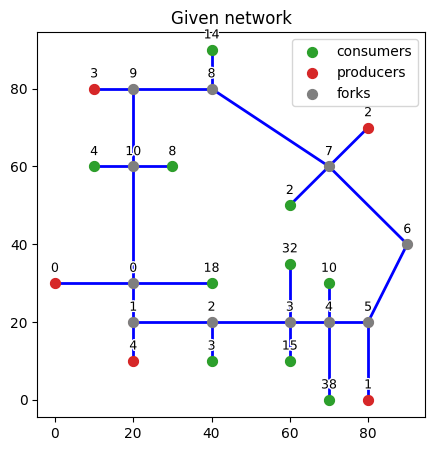

In [3]:
import matplotlib.patheffects as pe

# plot initial/given network
static_map = dhnx.plotting.StaticMap(network)
static_map.draw(background_map=False)
plt.title('Given network')

def scatter_with_labels(df, color, label):
    # scatter
    plt.scatter(df['lon'], df['lat'], color=color, label=label, zorder=2.5, s=50)
    # quali ID usare
    ids = df['id'] if 'id' in df.columns else df.index
    # etichette sopra i punti
    for _id, x, y in zip(ids, df['lon'], df['lat']):
        plt.annotate(
            str(_id), (x, y),
            xytext=(0, 6), textcoords='offset points',  # leggermente sopra
            ha='center', va='bottom', fontsize=9, zorder=3,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')]  # migliore leggibilità
        )

# Scatter + labels per ciascuna categoria
scatter_with_labels(network.components.consumers, 'tab:green', 'consumers')
scatter_with_labels(network.components.producers, 'tab:red', 'producers')
scatter_with_labels(network.components.forks,     'tab:grey', 'forks')

plt.legend()
plt.show()


## 1.2 Investment optimization of the network

In [4]:
solver_options = {'mipgap': 0.42}  # Set MIP gap to 42%

# Optimize the investment data
network.optimize_investment(invest_options=invest_opt,  solver='glpk', solver_cmdline_options=solver_options)

/opt/anaconda3/envs/env_P2/lib/python3.9/site-packages/oemof/solph/flows/_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)
/opt/anaconda3/envs/env_P2/lib/python3.9/site-packages/oemof/network/network/nodes.py:250: FutureWarning: Usage of oemof.network.Component is deprecated. Use oemof.network.Node instead.
  warnings.warn(


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --mipgap 0.42 --write /var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmpxywfk0w1.glpk.raw
 --wglp /var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmp3bpjzgtr.glpk.glp
 --cpxlp /var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmp__7y5pup.pyomo.lp
Reading problem data from '/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmp__7y5pup.pyomo.lp'...
/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmp__7y5pup.pyomo.lp:19412: warning: lower bound of variable 'x335' redefined
/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmp__7y5pup.pyomo.lp:19412: warning: upper bound of variable 'x335' redefined
3023 rows, 2669 columns, 6998 non-zeros
333 integer variables, all of which are binary
19745 lines were read
Writing problem data to '/var/folders/7p/sw30zsrs46z7txczcvfyfspm0000gn/T/tmp3bpjzgtr.glpk.glp'...
17037 lines were written
GLPK Integer Optimizer 5.0
3023 rows, 2669 columns, 6998 non-zeros
333 integer variable

/opt/anaconda3/envs/env_P2/lib/python3.9/site-packages/oemof/solph/_models.py:263: UserWarning: Optimization ended with status ok and termination condition feasible
  warnings.warn(


## 1.3 Results postprocessing and Plotting 


In [5]:
# ####### Postprocessing and Plotting ###########
results_edges = network.results.optimization['components']['pipes']
print(results_edges[['from_node', 'to_node', 'hp_type', 'capacity',
                     'direction', 'costs', 'losses']])

results_edges.to_csv("Outputs/STEP_2.results_edges.csv", index=True)

print('Objective value: ', network.results.optimization['oemof_meta']['objective'])

# assign new ThermalNetwork with invested pipes
twn_results = network
twn_results.components['pipes'] = results_edges[results_edges['capacity'] > 0.001]



      from_node       to_node hp_type  capacity  direction      costs  losses
id                                                                           
0   producers-0       forks-0   DN-50   358.273          1  14842.730   0.182
1   producers-1       forks-5  DN-100  1300.626          1  40866.260   0.480
26  producers-2       forks-7   DN-40   201.625          1  12456.250   0.190
27  producers-3       forks-9   DN-50   210.064          1  13360.640   0.182
28  producers-4       forks-1    None     0.000          0      0.000   0.000
2       forks-0       forks-1    None     0.000          0      0.000   0.000
3       forks-1       forks-2    None     0.000          0      0.000   0.000
4       forks-2       forks-3   DN-25    74.228         -1  10062.280   0.152
5       forks-3       forks-4   DN-80   882.699         -1  15553.495   0.190
6       forks-4       forks-5  DN-100  1300.146         -1  20430.730   0.240
7       forks-5       forks-6    None     0.000          0      

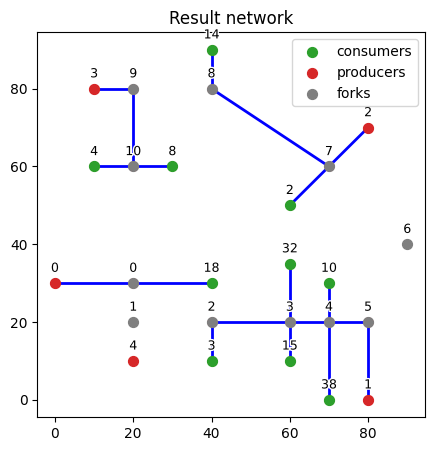

In [6]:
# Plot invested edges
static_map_2 = dhnx.plotting.StaticMap(twn_results)
static_map_2.draw(background_map=False)
plt.title('Result network')

# Define the function to plot points with labels
def scatter_with_labels(df, color, label):
    # Scatter plot for the points
    plt.scatter(df['lon'], df['lat'], color=color, label=label, zorder=2.5, s=50)
    
    # Determine which ID to use (column 'id' if it exists, otherwise the index)
    ids = df['id'] if 'id' in df.columns else df.index
    
    # Add labels (annotations) above each point
    for _id, x, y in zip(ids, df['lon'], df['lat']):
        plt.annotate(
            str(_id), (x, y),
            xytext=(0, 6), textcoords='offset points',  # Position slightly above the point
            ha='center', va='bottom', fontsize=9, zorder=3,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')]  # White outline for readability
        )

# Apply the function to consumers, producers, and forks
# (Using 'network.components' as the source for coordinates and IDs)
scatter_with_labels(network.components.consumers, 'tab:green', 'consumers')
scatter_with_labels(network.components.producers, 'tab:red', 'producers')
scatter_with_labels(network.components.forks,     'tab:grey', 'forks')

plt.legend()
plt.show()

## Step 2 questions


### How did increasing the number of consumers and producers affect the network topology and pipe selection?



Adding producers and consumers provided a more flexible possible network system.

The network is not a big single loop anymore but a decentralized system. 
Producers now serve as a main provider locally for nearby consumers. This enables a more efficient and cost-effective network design with the potential for shorter pipes length in local distribution runs. The pipes were selected according to the demand capacity of different connections. a more diverse range of diameter compared to the limited types used in Step 1. And not every producer was needed to supply heat.

### Did the optimizer choose different pipe types compared to Step 1? Why?

In step1, only two types of pipes can be used. However, the actual capacities for the DN-32 and DN-50 are too low to meet the system heat requirement. We increased the capacity for both types of pipes in the step 1. Optimization in step 1 just selected the same type of types that could meet the all system demand. From the optimization result in step2, optimizated results showed diversed types of pipes choose based on the capacity demand of each connection for the consumers. 




### Are the additional producers utilized efficiently, or are some underuse? 
 One producer did not connect to any consumers. 
Yes most of the proudcers supply to at least two consumers. There are two proudcers either supply no consumer or only one consumer.



### How are the total investment costs, operating costs, and losses compared with the smaller network in Step 1?


The optimization in Step 2 resulted in a higher Total Investment Cost Objective value: 249414.77€ vs. 117455.01€ in Step 1. This is primarily because the network expanded to serve more consumers, leading to longer total pipe lengths and the selection of larger diameter pipes (up to DN-125) for main transmission lines.

Due to the longer built network, the new loads added, and the selection of larger pipes (which have a higher surface area), the total Thermal Loss Factor Sum increased by 92.8% (from 1.674 to 3.228). This higher loss factor directly contributes to higher Operational Costs.


